# Bangladesh Renewable Energy Resource Analysis

## Comprehensive visualization of Bangladesh's solar and wind energy potential across 8 administrative divisions

### Authors: 
- Md Eliasinul Islam (Elias Islam)
- Sustainable Energy Engineering, Simon Fraser University, BC, Canada

### Study Coverage:
- **Country**: Bangladesh  
- **Administrative Divisions**: 8 (Barisal, Chittagong, Dhaka, Khulna, Mymensingh, Rajshahi, Rangpur, Sylhet)
- **Resource Types**: Solar PV and Wind Energy
- **Data Sources**: ERA5, GAEZ, Global Wind Atlas, OpenStreetMap, WorldPop

---

## Section 1: Import Required Libraries

In [23]:
import warnings
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import pandas as pd
import rasterio as rio
import rioxarray as rxr
import numpy as np
import seaborn as sns
from matplotlib.colors import ListedColormap, BoundaryNorm, to_rgba
from matplotlib.patches import Patch

import RES.visuals as vis
from RES import utility as utils
from RES.hdf5_handler import DataHandler
import RES.utility as utlis

# Set plotting style
plt.style.use('../RES/visual_styles/elsevier.mplstyle')

# Suppress specific warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

print("✓ All required libraries imported successfully!")

✓ All required libraries imported successfully!


## Section 2: Load Configuration and Data

In [24]:
# Load configuration file
cfg = utils.load_config('../config/config_BGD.yaml')
sub_national_unit_tag = cfg.get('GADM').get('datafield_mapping').get('NAME_1')
country_name = cfg.get('country', 'Bangladesh')
country_kwd = country_name.replace(' ', '')

# Define all 8 administrative divisions of Bangladesh
regions = ['BD-01', 'BD-02', 'BD-03', 'BD-04', 'BD-05', 'BD-06', 'BD-07', 'BD-08']
region_names = {
    'BD-01': 'Barisal',
    'BD-02': 'Chittagong', 
    'BD-03': 'Dhaka',
    'BD-04': 'Khulna',
    'BD-05': 'Mymensingh',
    'BD-06': 'Rajshahi',
    'BD-07': 'Rangpur',
    'BD-08': 'Sylhet'
}

print(f"✓ Configuration loaded for {country_name}")
print(f"✓ Administrative divisions: {list(region_names.values())}")

✓ Configuration loaded for Bangladesh
✓ Administrative divisions: ['Barisal', 'Chittagong', 'Dhaka', 'Khulna', 'Mymensingh', 'Rajshahi', 'Rangpur', 'Sylhet']


In [25]:
# Load processed data stores for all regions
RUN_ID = 'baseline'  # All the regions should have RUN_ID results available
BGD_store = {}

utils.print_update(level=1, message=f"Loading data stores for Bangladesh regions with RUN_ID: {RUN_ID}")

for region in regions:
    country_dict = {}
    try:
        store = Path(f"../data/store/resources_{country_kwd}_{region}_{RUN_ID}.h5")
        if store.exists():
            res_data = DataHandler(store, show_structure=False)
            country_dict['cells'] = res_data.from_store('cells')
            country_dict['boundary'] = res_data.from_store('boundary')
            try:
                country_dict['lines'] = res_data.from_store('lines')
            except:
                print(f"  No transmission line data for {region}")
                country_dict['lines'] = None
            BGD_store[region] = country_dict
            utils.print_update(level=2, message=f"✓ Loaded data for region: {region} ({region_names[region]})")
        else:
            print(f"  ⚠️  Store not found for region {region} ({region_names[region]}): {store}")
    except Exception as e:
        print(f"  ❌ Error with region {region} ({region_names[region]}): {e}")
        continue

print(f"\n✓ Successfully loaded data for {len(BGD_store)} out of {len(regions)} regions")
available_regions = list(BGD_store.keys())
print(f"Available regions: {[f'{r} ({region_names[r]})' for r in available_regions]}")

└> Loading data stores for Bangladesh regions with RUN_ID: baseline
  └> RES.hdf5_handler| ❌ Error: Key 'cells' not found in ../data/store/resources_Bangladesh_BD-01_baseline.h5
  └> RES.hdf5_handler| ❌ Error: Key 'boundary' not found in ../data/store/resources_Bangladesh_BD-01_baseline.h5
  └> RES.hdf5_handler| ❌ Error: Key 'lines' not found in ../data/store/resources_Bangladesh_BD-01_baseline.h5
 └> ✓ Loaded data for region: BD-01 (Barisal)
  ⚠️  Store not found for region BD-02 (Chittagong): ../data/store/resources_Bangladesh_BD-02_baseline.h5
 └> ✓ Loaded data for region: BD-03 (Dhaka)
  ⚠️  Store not found for region BD-04 (Khulna): ../data/store/resources_Bangladesh_BD-04_baseline.h5
  ⚠️  Store not found for region BD-05 (Mymensingh): ../data/store/resources_Bangladesh_BD-05_baseline.h5
  ⚠️  Store not found for region BD-06 (Rajshahi): ../data/store/resources_Bangladesh_BD-06_baseline.h5
  ⚠️  Store not found for region BD-07 (Rangpur): ../data/store/resources_Bangladesh_BD-07_

### Load Validation Data (if available)

In [26]:
# Load existing renewable energy projects data for Bangladesh (if available)
existing_VREs_data_path = Path("../data/validation_data/existing_VREs_Bangladesh.csv")

if existing_VREs_data_path.exists():
    existing_VREs = pd.read_csv(existing_VREs_data_path)
    existing_VREs_gdf = gpd.GeoDataFrame(
        existing_VREs, 
        geometry=gpd.points_from_xy(existing_VREs.Longitude, existing_VREs.Latitude), 
        crs="EPSG:4326"
    )
    utils.print_update(level=1, message=f"✓ Loaded validation data for existing VREs from {existing_VREs_data_path}")
    print(f"  Found {len(existing_VREs_gdf)} existing renewable energy projects")
else:
    existing_VREs_gdf = None
    utils.print_warning(f"⚠️  Validation data for existing VREs not found at {existing_VREs_data_path}")
    print("  You can create this file with columns: Project_Name, Technology, Capacity_MW, Longitude, Latitude")

⚠️  ⚠️  Validation data for existing VREs not found at ../data/validation_data/existing_VREs_Bangladesh.csv
  You can create this file with columns: Project_Name, Technology, Capacity_MW, Longitude, Latitude


## Section 3: Create Country Overview Map

In [27]:
BGD_store = {'BD-03': BGD_store['BD-03']}

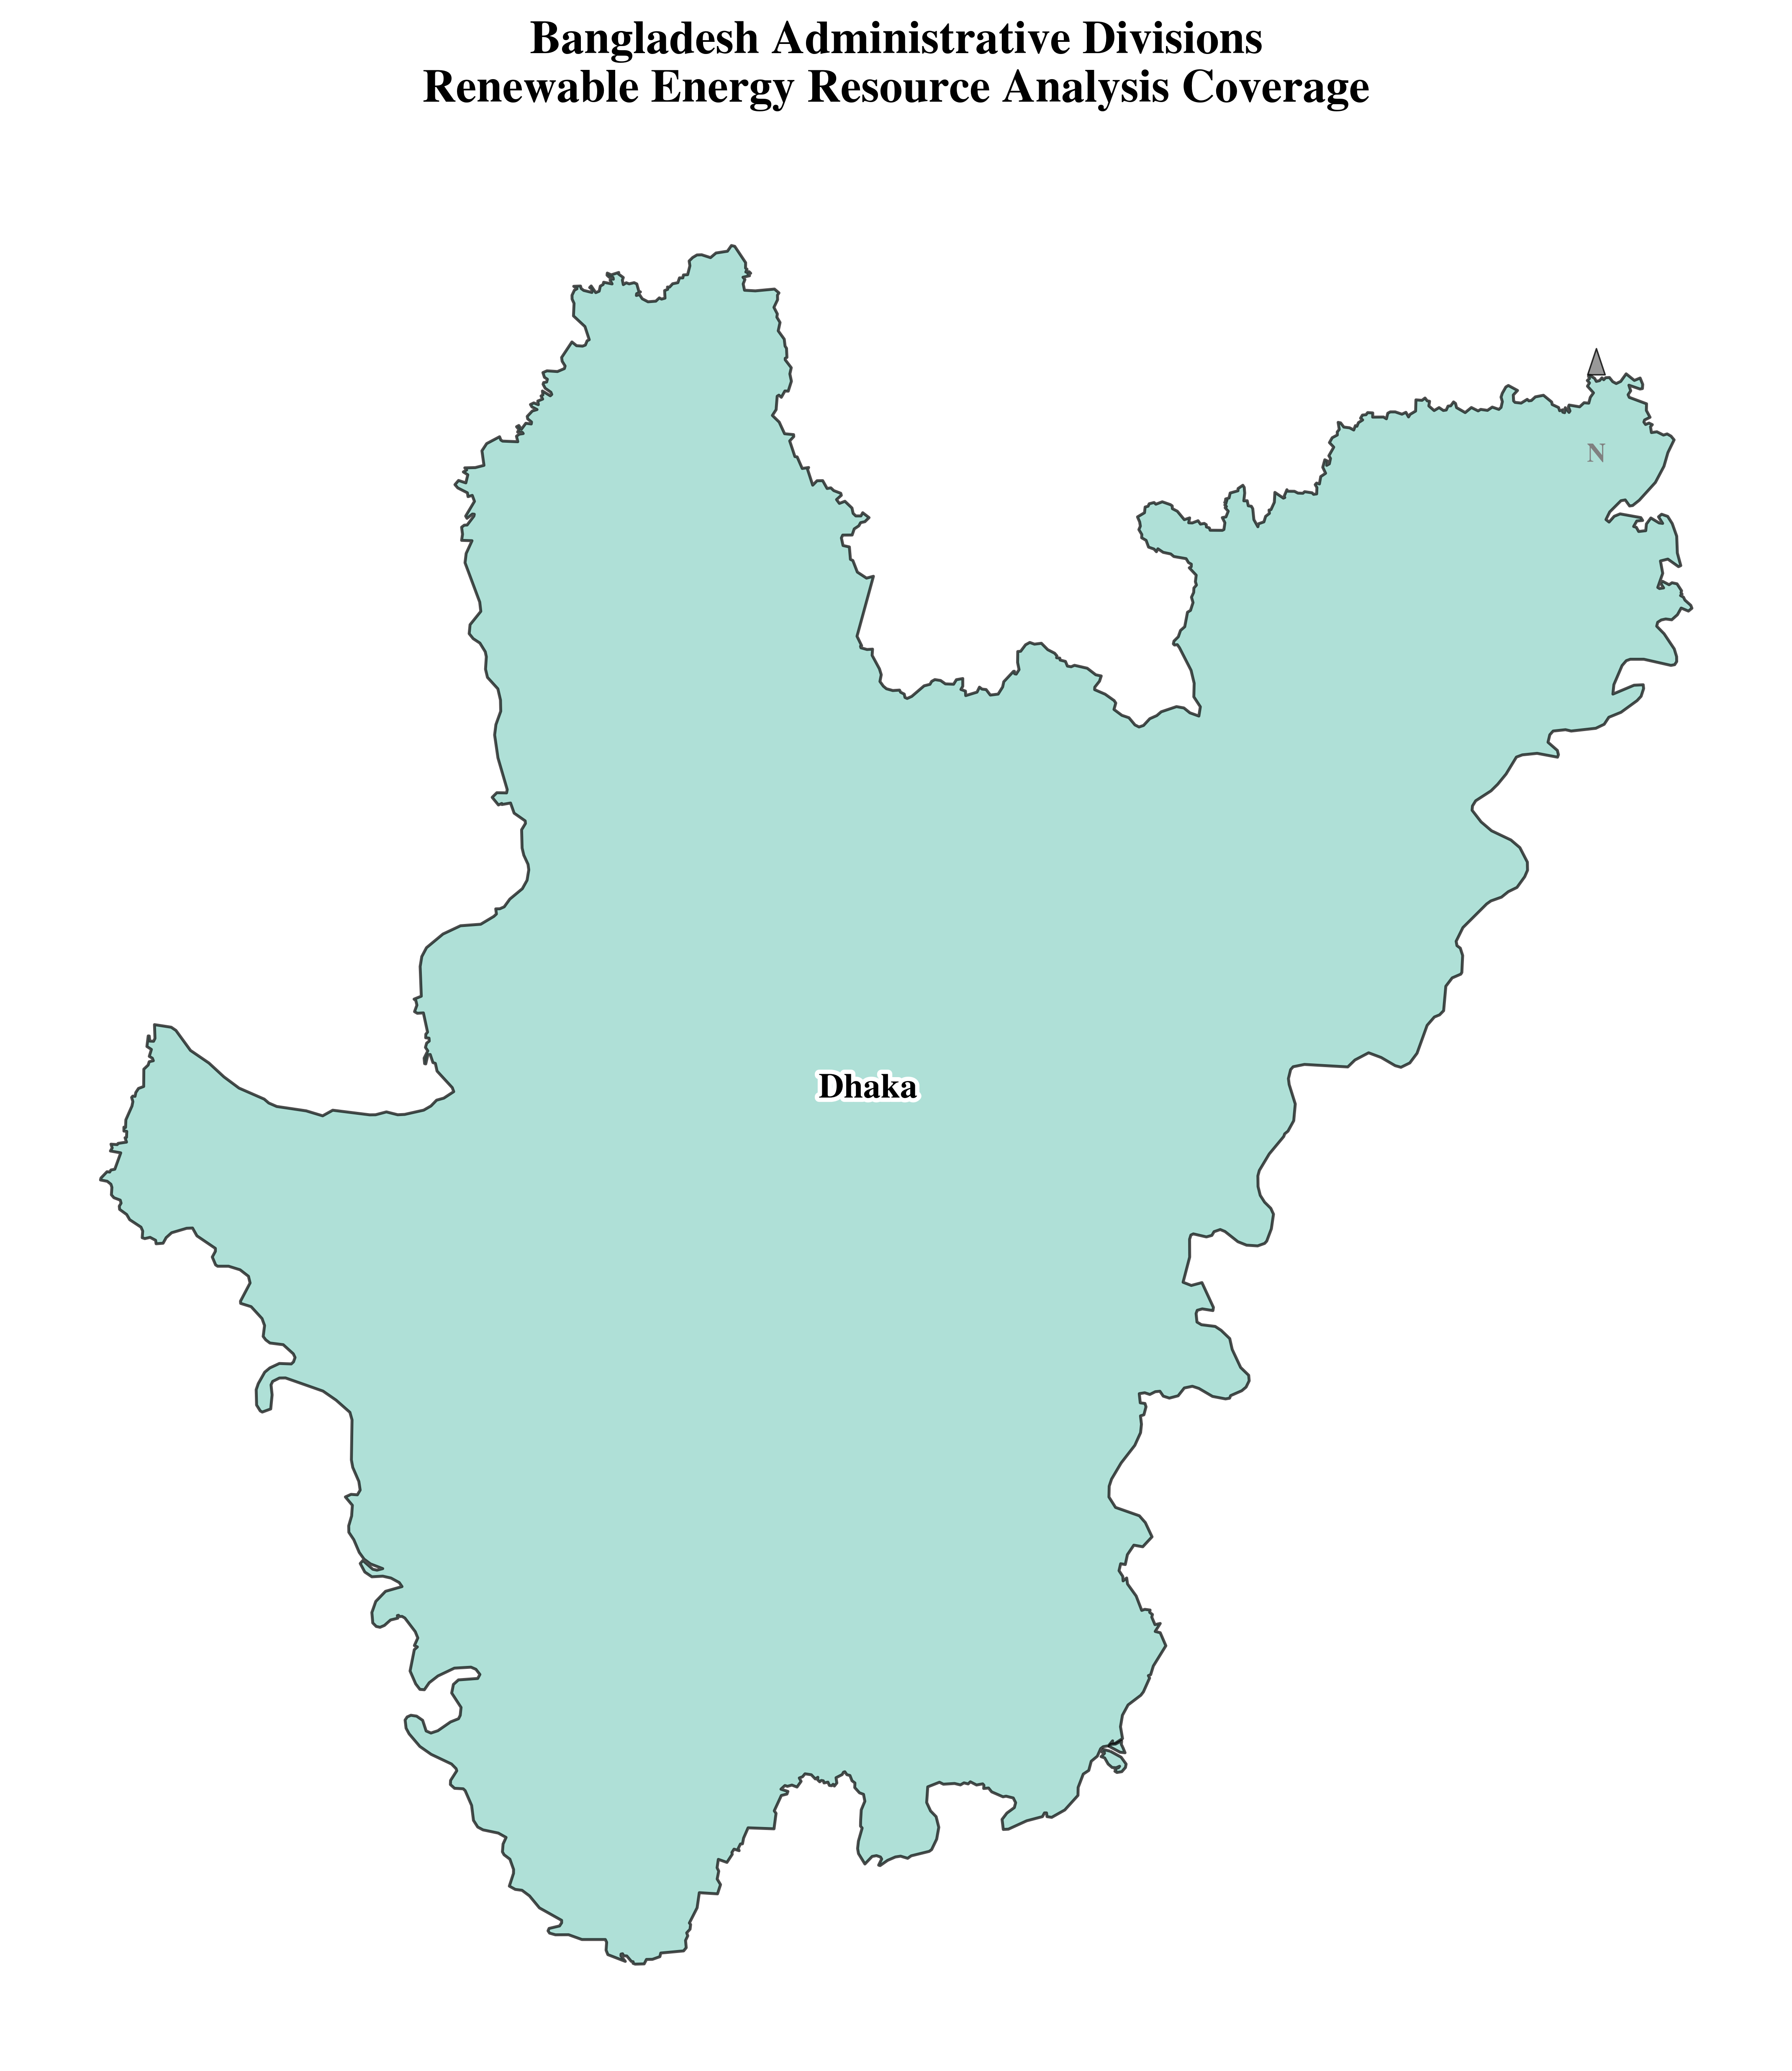

✓ Country overview map saved to: ../vis/Bangladesh/Bangladesh_Administrative_Divisions.png


In [28]:
# Create combined boundary for Bangladesh
if BGD_store:
    # Combine all region boundaries into a single GeoDataFrame
    boundary_gdfs = [BGD_store[region]['boundary'] for region in BGD_store]
    BGD_boundary = gpd.GeoDataFrame(pd.concat(boundary_gdfs, ignore_index=True), crs=boundary_gdfs[0].crs)
    BGD_boundary_dissolved = BGD_boundary.dissolve(by="Country")[["geometry"]].reset_index()
    
    # Create a map showing all administrative divisions
    fig, ax = plt.subplots(figsize=(12, 10))
    
    # Plot individual boundaries with different colors
    colors = plt.cm.Set3(np.linspace(0, 1, len(BGD_store)))
    
    for i, (region, data) in enumerate(BGD_store.items()):
        boundary = data['boundary']
        boundary.plot(ax=ax, color=colors[i], alpha=0.7, edgecolor='black', linewidth=1)
        
        # Add division labels
        centroid = boundary.geometry.centroid.iloc[0]
        ax.annotate(
            f"{region_names[region]}",
            (centroid.x, centroid.y),
            ha="center", va="center",
            fontsize=12, fontweight="bold", color="black",
            path_effects=[pe.withStroke(linewidth=3, foreground="white")]
        )
    
    # Add existing VREs if available
    if existing_VREs_gdf is not None:
        existing_VREs_gdf.plot(ax=ax, color='red', markersize=100, alpha=0.8, 
                              label='Existing Renewable Energy Projects')
        ax.legend(loc='upper right')
    
    ax.set_title("Bangladesh Administrative Divisions\nRenewable Energy Resource Analysis Coverage", 
                 fontsize=16, fontweight='bold', pad=20)
    ax.set_axis_off()
    
    # Add compass
    vis.add_compass_arrow_custom(ax, text_offset=0.04)
    
    plt.tight_layout()
    
    # Save the map
    save_path = Path(f'../vis/{country_kwd}/Bangladesh_Administrative_Divisions.png')
    save_path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    plt.show()
    
    print(f"✓ Country overview map saved to: {save_path}")
else:
    print("❌ No boundary data available to create country overview map")

## Section 4: Display Land Use Constraints (GAEZ Analysis)

In [29]:
# Load GAEZ land cover legends and class mappings
GAEZ_legends = pd.read_csv("../data/faocmb_2010_legend.csv") if Path("../data/faocmb_2010_legend.csv").exists() else None
class_inclusion_layers = cfg.get('GAEZ', {}).get('raster_types', [])

if class_inclusion_layers:
    # Find land cover configuration
    land_cover_config = None
    for raster_type in class_inclusion_layers:
        if raster_type.get('name') == 'land_cover':
            land_cover_config = raster_type
            break
    
    if land_cover_config and BGD_boundary_dissolved is not None:
        print("✓ Found GAEZ land cover configuration")
        print(f"  Solar suitable classes: {land_cover_config.get('class_inclusion', {}).get('solar', [])}")
        print(f"  Wind suitable classes: {land_cover_config.get('class_inclusion', {}).get('wind', [])}")
        
        # Define raster path for GAEZ land cover
        GAEZ_raster_path = Path('../Rasters_in_use/faocmb_2010.tif')
        
        if GAEZ_raster_path.exists():
            print(f"✓ Found GAEZ raster at: {GAEZ_raster_path}")
            
            # Reproject boundary to UTM for clipping
            BGD_boundary_utm = BGD_boundary_dissolved.to_crs(epsg=32646)  # UTM Zone 46N for Bangladesh
            
            # Get bounds for clipping
            minx, miny, maxx, maxy = BGD_boundary_utm.total_bounds
            bounding_box_dict = {
                "minx": float(minx),
                "miny": float(miny), 
                "maxx": float(maxx),
                "maxy": float(maxy)
            }
            
            try:
                # Load and clip raster to Bangladesh boundary
                GAEZ_raster_data = (
                    rxr.open_rasterio(GAEZ_raster_path)
                    .rio.reproject("EPSG:32646")  # Reproject to UTM
                    .rio.clip_box(**bounding_box_dict)
                )
                print("✓ Successfully loaded and clipped GAEZ land cover data")
                
                # Extract unique land cover classes
                codes = np.unique(GAEZ_raster_data.values[~np.isnan(GAEZ_raster_data.values)])
                codes = codes.astype(int)
                print(f"  Found {len(codes)} unique land cover classes in Bangladesh")
                
            except Exception as e:
                print(f"❌ Error loading GAEZ raster: {e}")
                GAEZ_raster_data = None
                
        else:
            print(f"⚠️  GAEZ raster not found at: {GAEZ_raster_path}")
            GAEZ_raster_data = None
    else:
        print("⚠️  No land cover configuration found in GAEZ settings")
        GAEZ_raster_data = None
else:
    print("⚠️  No GAEZ raster configuration found")
    GAEZ_raster_data = None

✓ Found GAEZ land cover configuration
  Solar suitable classes: [2, 3, 5, 6, 8, 9]
  Wind suitable classes: [2, 3, 5, 6, 8, 9]
⚠️  GAEZ raster not found at: ../Rasters_in_use/faocmb_2010.tif


## Section 5: Visualize Solar Resource Distribution

✓ Combined data from 1 regions
  Total grid cells: 51
  Available solar data columns: ['potential_capacity_solar', 'capex_solar', 'fom_solar', 'vom_solar', 'grid_connection_cost_per_km_solar', 'tx_line_rebuild_cost_solar', 'Operational_life_solar', 'solar_CF_mean', 'lcoe_solar', 'lcoe_actualCap_solar']
 └> Please cross check with Solar CF map with GLobal Solar Atlas Data from : https://globalsolaratlas.info/download/country_name


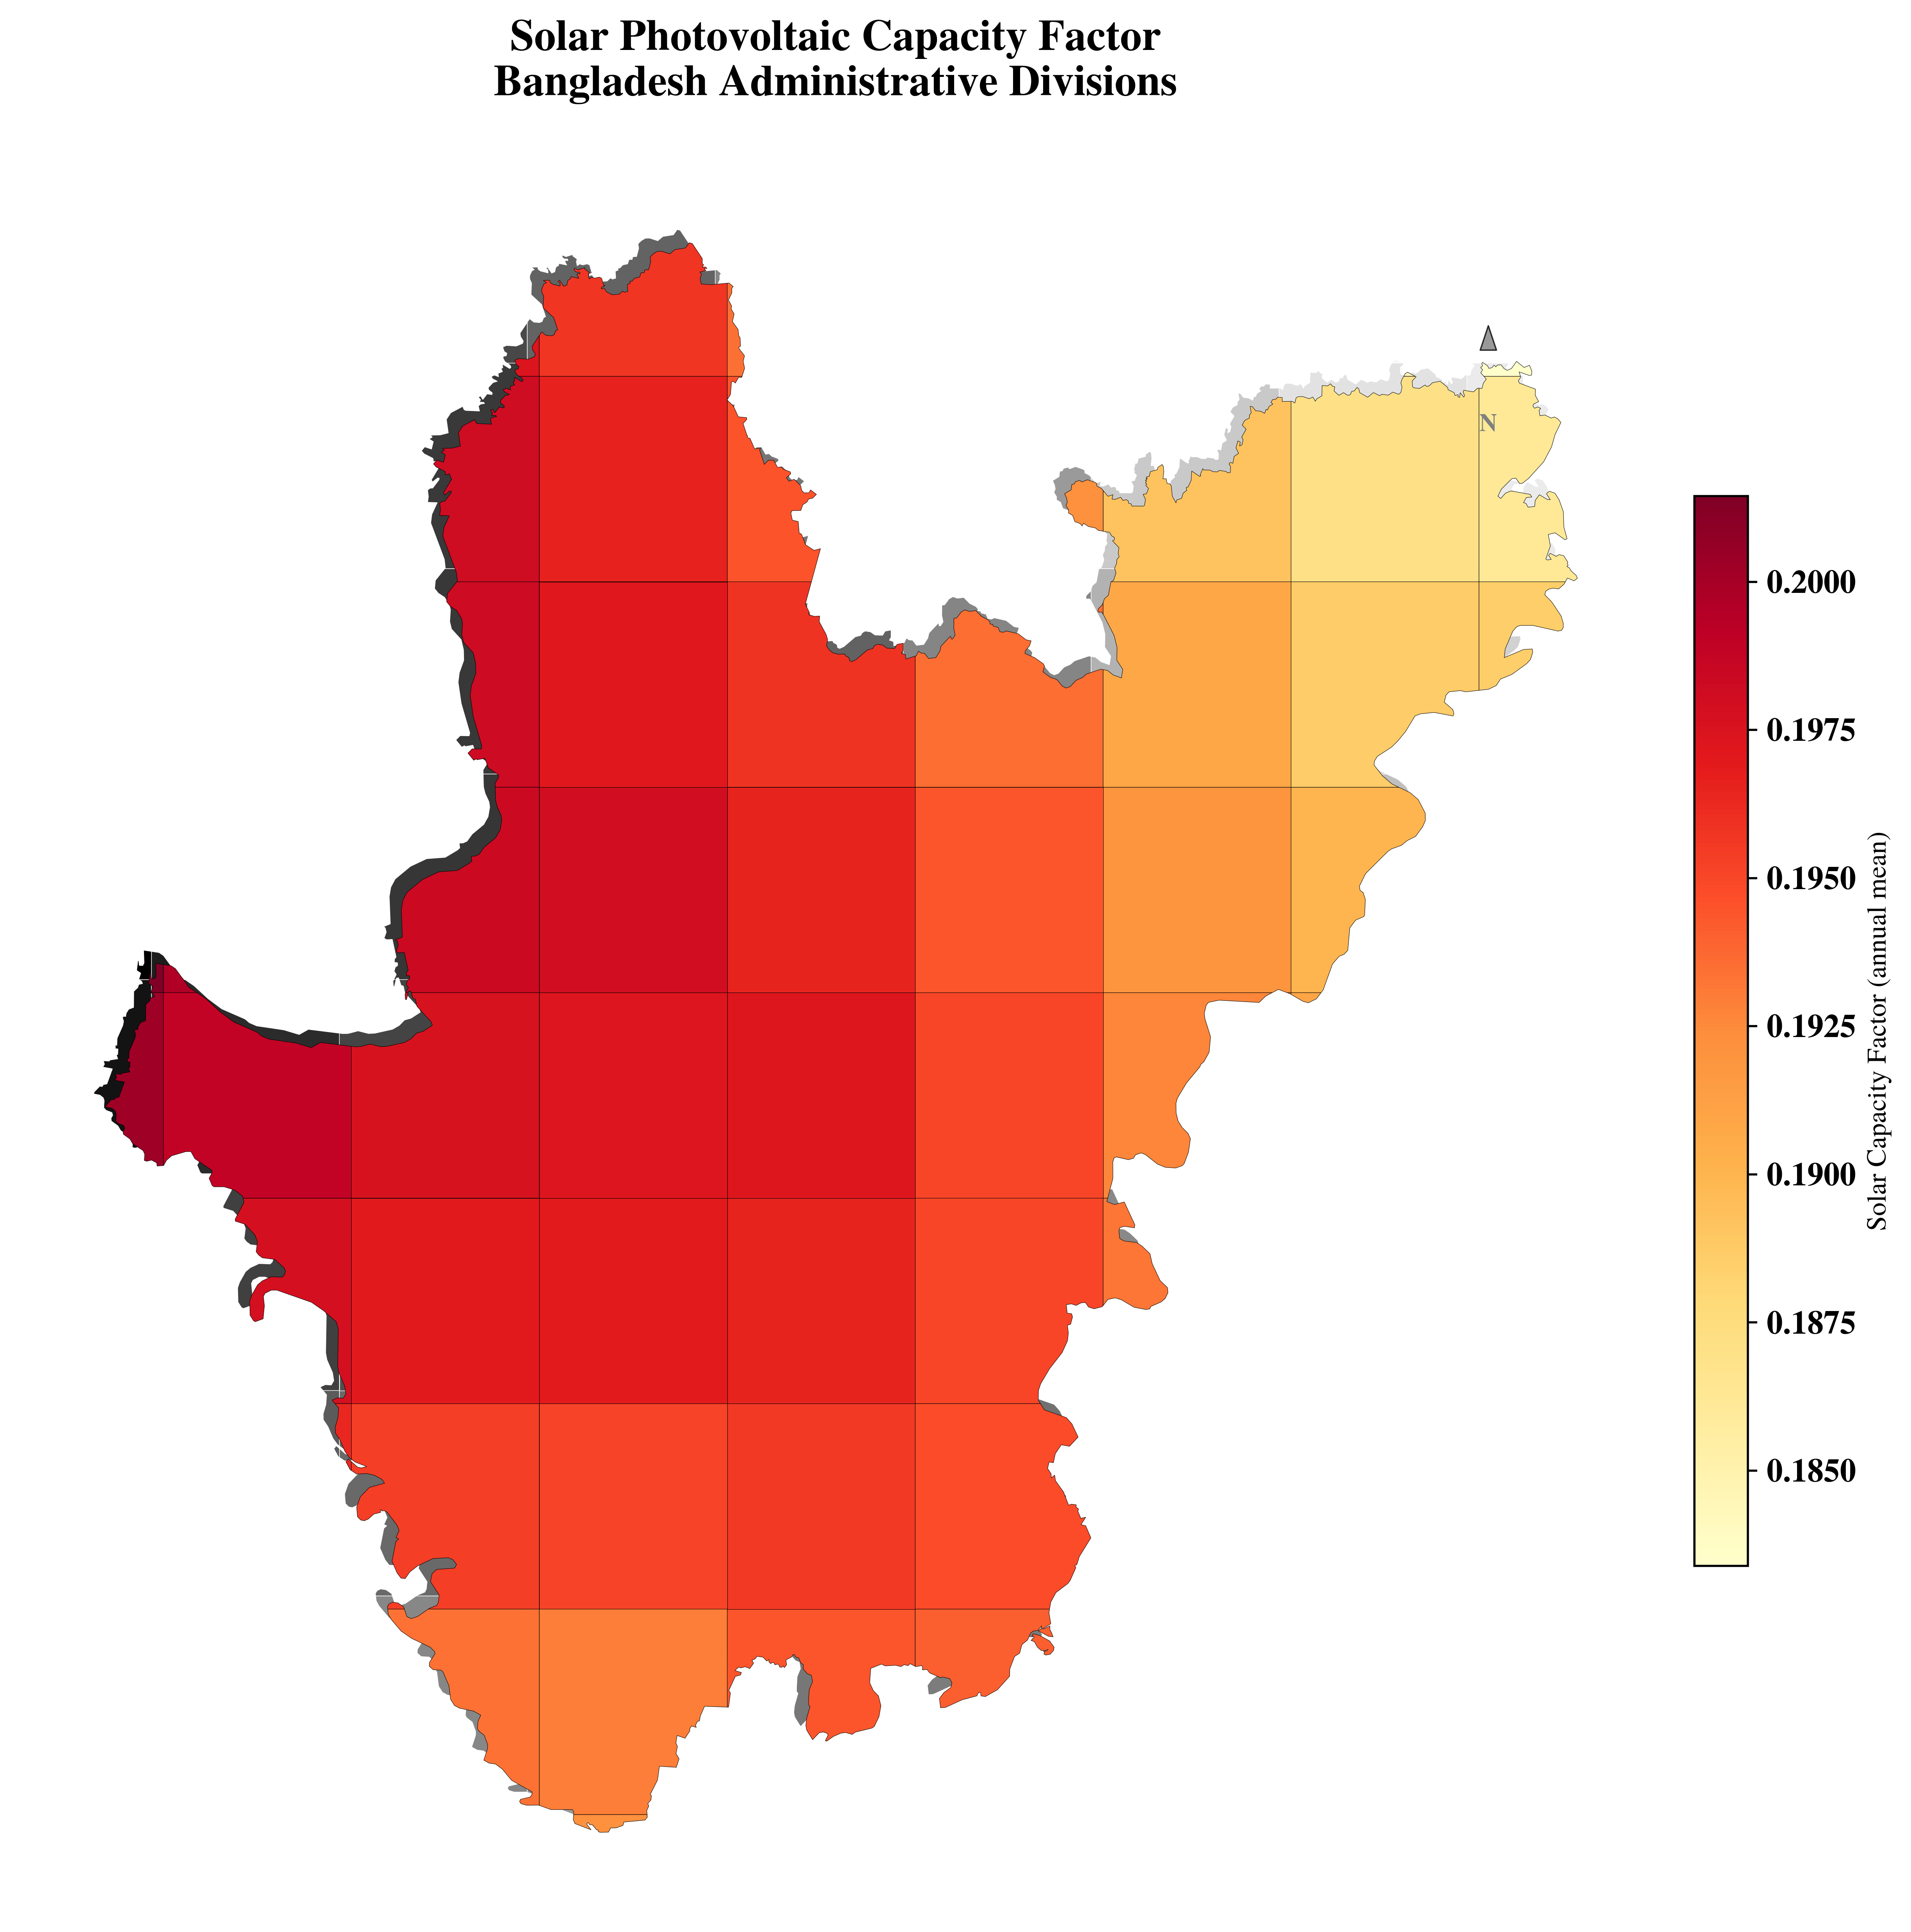

✓ Solar CF map saved to: ../vis/Bangladesh/Bangladesh_Solar_CF.png


In [30]:
# Combine all cell data for comprehensive solar analysis
if BGD_store:
    all_cells = [BGD_store[region]['cells'] for region in BGD_store]
    BGD_cells = gpd.GeoDataFrame(pd.concat(all_cells, ignore_index=True), crs=all_cells[0].crs)
    
    print(f"✓ Combined data from {len(BGD_store)} regions")
    print(f"  Total grid cells: {len(BGD_cells)}")
    
    # Check available solar data columns
    solar_columns = [col for col in BGD_cells.columns if 'solar' in col.lower()]
    print(f"  Available solar data columns: {solar_columns}")
    
    # Create solar resource visualizations
    if 'solar_CF_mean' in BGD_cells.columns or any('CF' in col and 'solar' in col for col in BGD_cells.columns):
        
        # Find the correct CF column
        cf_column = None
        for col in BGD_cells.columns:
            if 'solar_CF_mean' == col:
                cf_column = col
                break
            elif 'CF' in col and 'solar' in col:
                cf_column = col
                break
        
        if cf_column:
            fig, ax = plt.subplots(figsize=(12, 10))
            
            # Plot solar capacity factor
            vis.get_data_in_map_plot(
                BGD_cells, 
                resource_type='solar',
                datafield='CF',
                ax=ax, 
                show=False
            )
            
            # Add existing VREs if available
            if existing_VREs_gdf is not None:
                solar_projects = existing_VREs_gdf[
                    existing_VREs_gdf['Technology'].str.lower().str.contains('solar', na=False)
                ]
                if len(solar_projects) > 0:
                    solar_projects.plot(
                        ax=ax, color='None', edgecolor='orangered', 
                        markersize=100, linewidth=2, marker='s', 
                        alpha=1, zorder=5, label='Existing Solar Projects'
                    )
                    ax.legend(loc='upper right', fontsize=10, frameon=True)
            
            ax.set_title("Solar Photovoltaic Capacity Factor\nBangladesh Administrative Divisions", 
                        fontsize=16, fontweight='bold', pad=20)
            
            # Add compass
            vis.add_compass_arrow_custom(ax, text_offset=0.04)
            
            plt.tight_layout()
            
            # Save the plot
            save_path = Path(f'../vis/{country_kwd}/Bangladesh_Solar_CF.png')
            save_path.parent.mkdir(parents=True, exist_ok=True)
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            
            plt.show()
            
            print(f"✓ Solar CF map saved to: {save_path}")
        else:
            print("⚠️  No solar capacity factor data found")
    else:
        print("⚠️  No solar resource data available")
        
else:
    print("❌ No cell data available for solar resource visualization")

## Section 6: Visualize Solar Capacity Potential

 └> Please cross check with Solar CF map with GLobal Solar Atlas Data from : https://globalsolaratlas.info/download/country_name


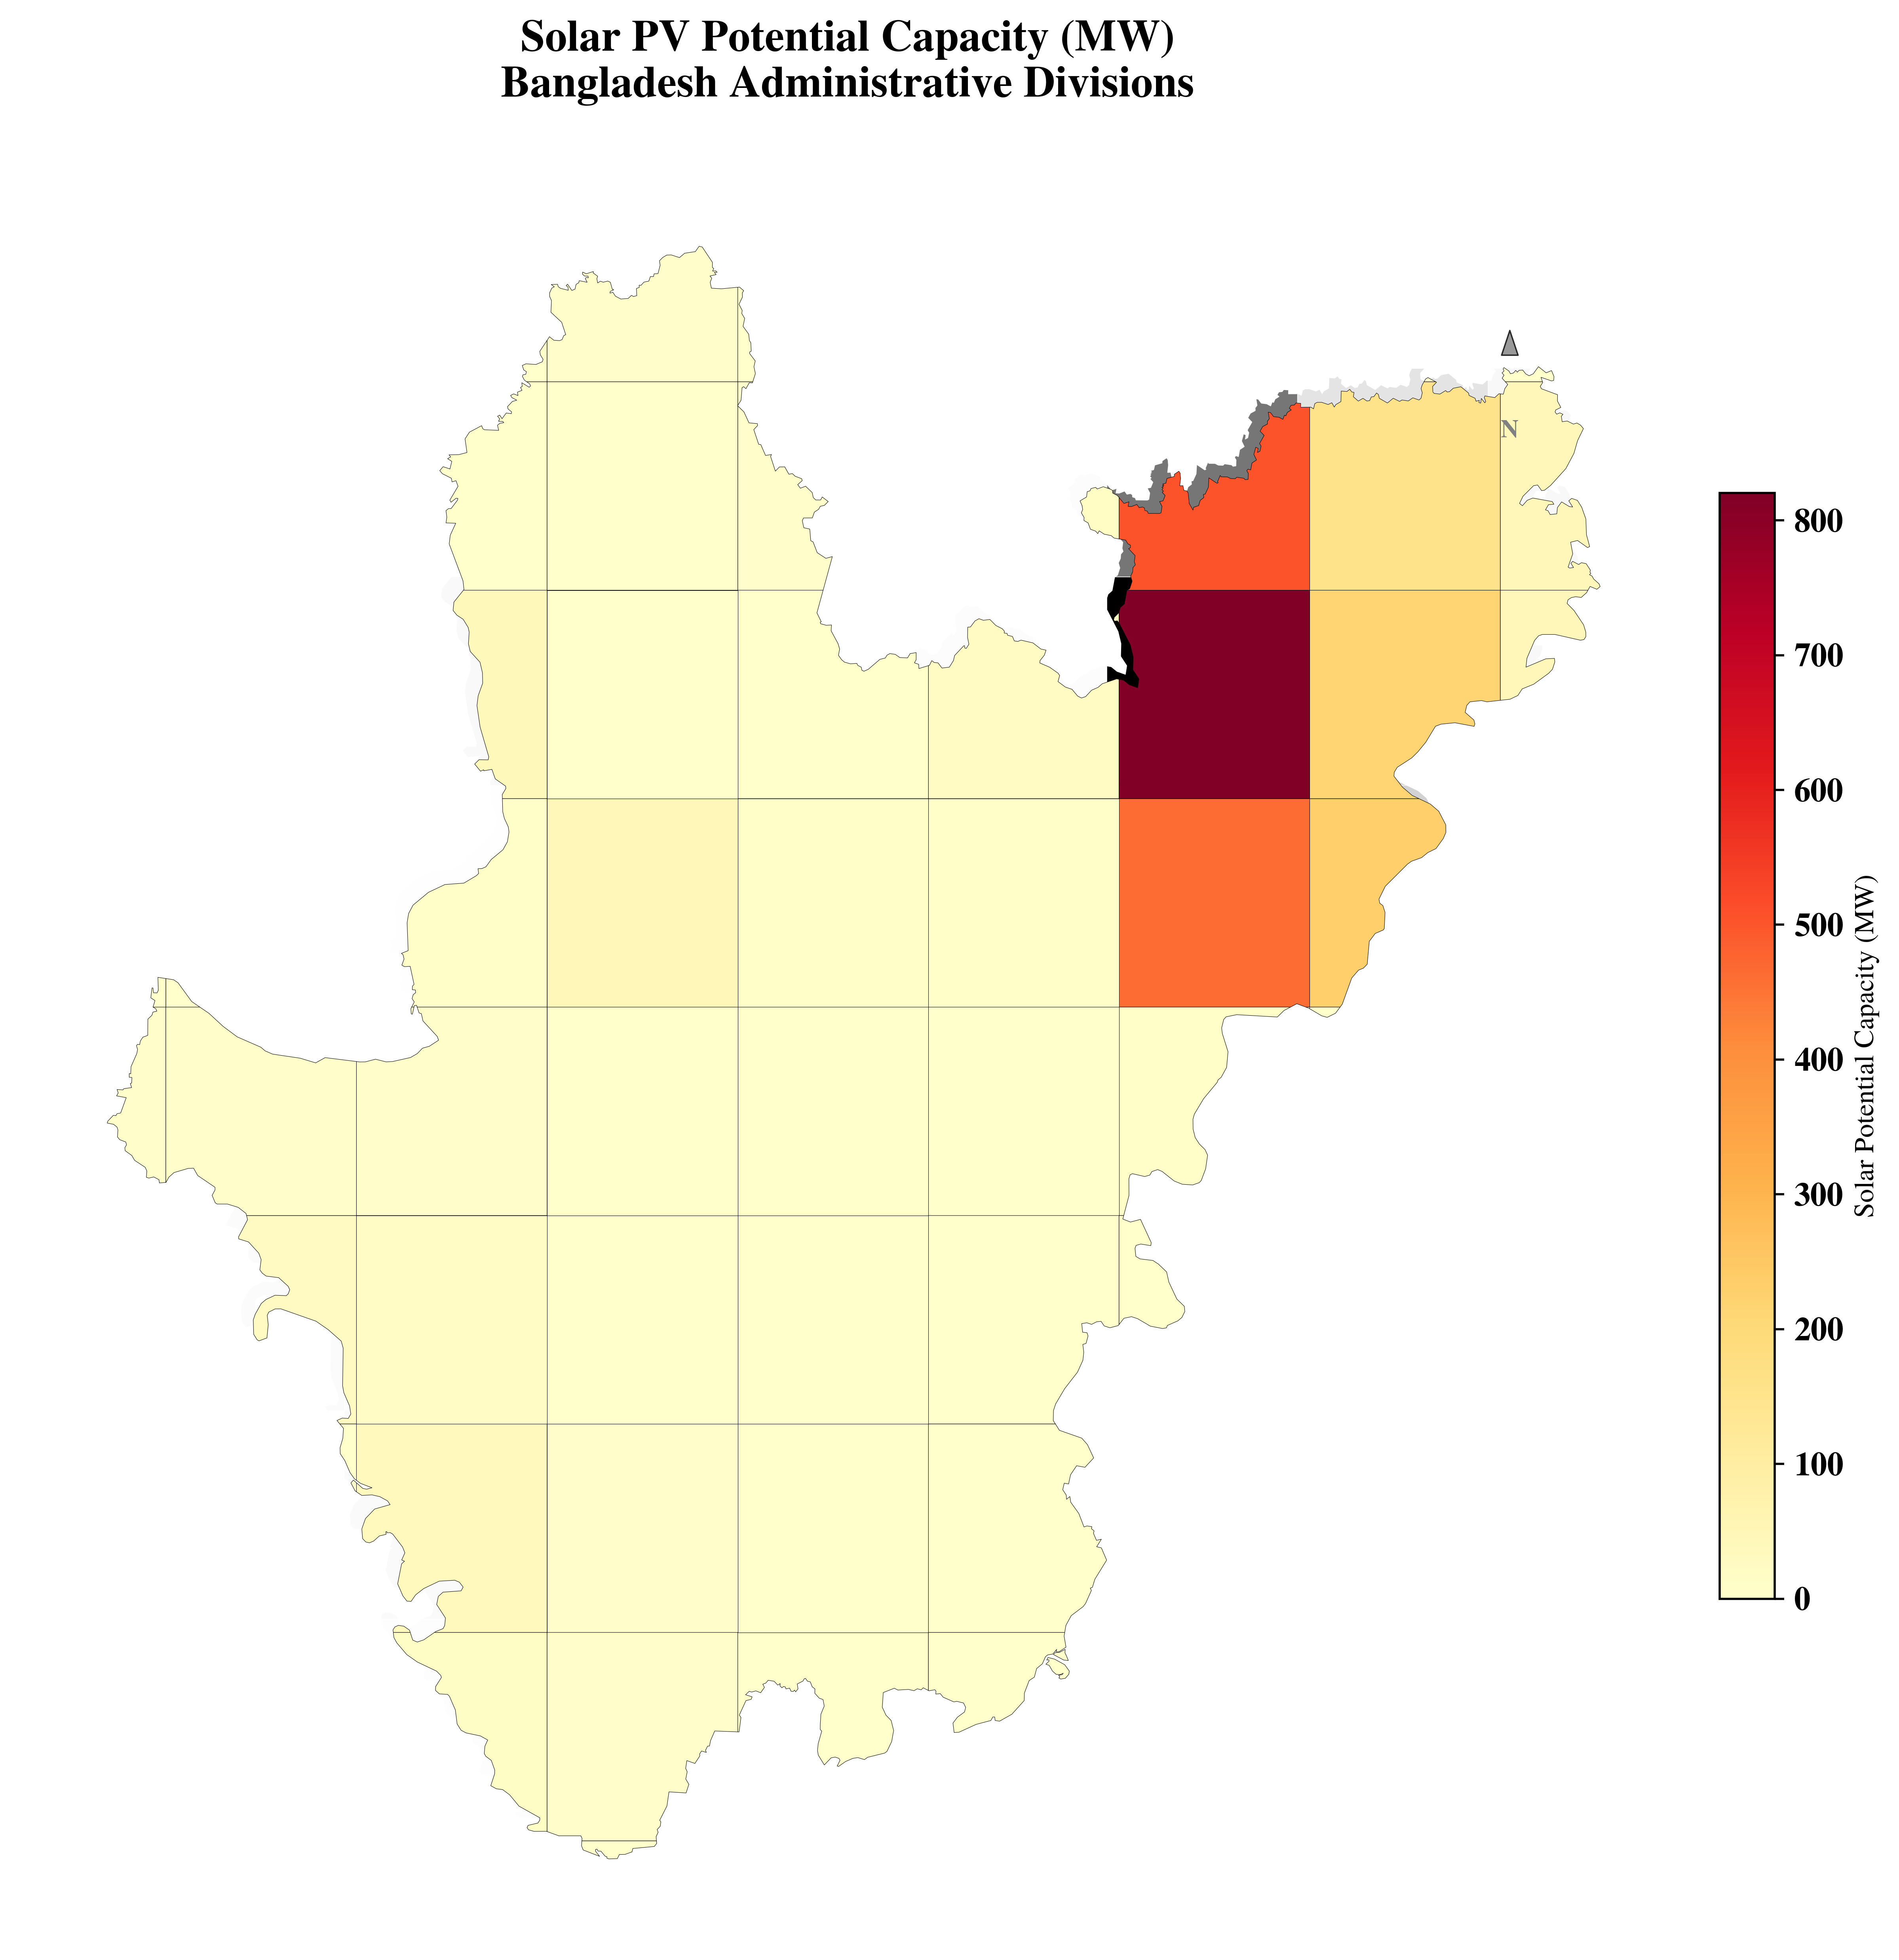

✓ Solar capacity map saved to: ../vis/Bangladesh/Bangladesh_Solar_Capacity.png

📊 Solar Capacity Summary:
  Total potential capacity: 2.8 GW
  Maximum cell capacity: 820.3 MW
  Average cell capacity: 54.5 MW


In [31]:
# Visualize solar capacity potential
if BGD_store and 'potential_capacity_solar' in BGD_cells.columns:
    
    fig, ax = plt.subplots(figsize=(12, 10))
    
    # Plot solar capacity potential
    vis.get_data_in_map_plot(
        BGD_cells, 
        resource_type='solar',
        datafield='capacity',
        ax=ax, 
        show=False
    )
    
    # Add existing VREs if available
    if existing_VREs_gdf is not None:
        solar_projects = existing_VREs_gdf[
            existing_VREs_gdf['Technology'].str.lower().str.contains('solar', na=False)
        ]
        if len(solar_projects) > 0:
            solar_projects.plot(
                ax=ax, color='None', edgecolor='orangered', 
                markersize=100, linewidth=2, marker='s', 
                alpha=1, zorder=5, label='Existing Solar Projects'
            )
            ax.legend(loc='upper right', fontsize=10, frameon=True)
    
    ax.set_title("Solar PV Potential Capacity (MW)\nBangladesh Administrative Divisions", 
                fontsize=16, fontweight='bold', pad=20)
    
    # Add compass
    vis.add_compass_arrow_custom(ax, text_offset=0.04)
    
    plt.tight_layout()
    
    # Save the plot
    save_path = Path(f'../vis/{country_kwd}/Bangladesh_Solar_Capacity.png')
    save_path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    plt.show()
    
    # Calculate and display summary statistics
    total_solar_capacity = BGD_cells['potential_capacity_solar'].sum()
    max_solar_capacity = BGD_cells['potential_capacity_solar'].max()
    mean_solar_capacity = BGD_cells['potential_capacity_solar'].mean()
    
    print(f"✓ Solar capacity map saved to: {save_path}")
    print(f"\n📊 Solar Capacity Summary:")
    print(f"  Total potential capacity: {total_solar_capacity/1000:.1f} GW")
    print(f"  Maximum cell capacity: {max_solar_capacity:.1f} MW")
    print(f"  Average cell capacity: {mean_solar_capacity:.1f} MW")
    
else:
    print("⚠️  No solar capacity data available for visualization")

## Section 7: Generate LCOE Analysis

 └> Please cross check with Solar CF map with GLobal Solar Atlas Data from : https://globalsolaratlas.info/download/country_name


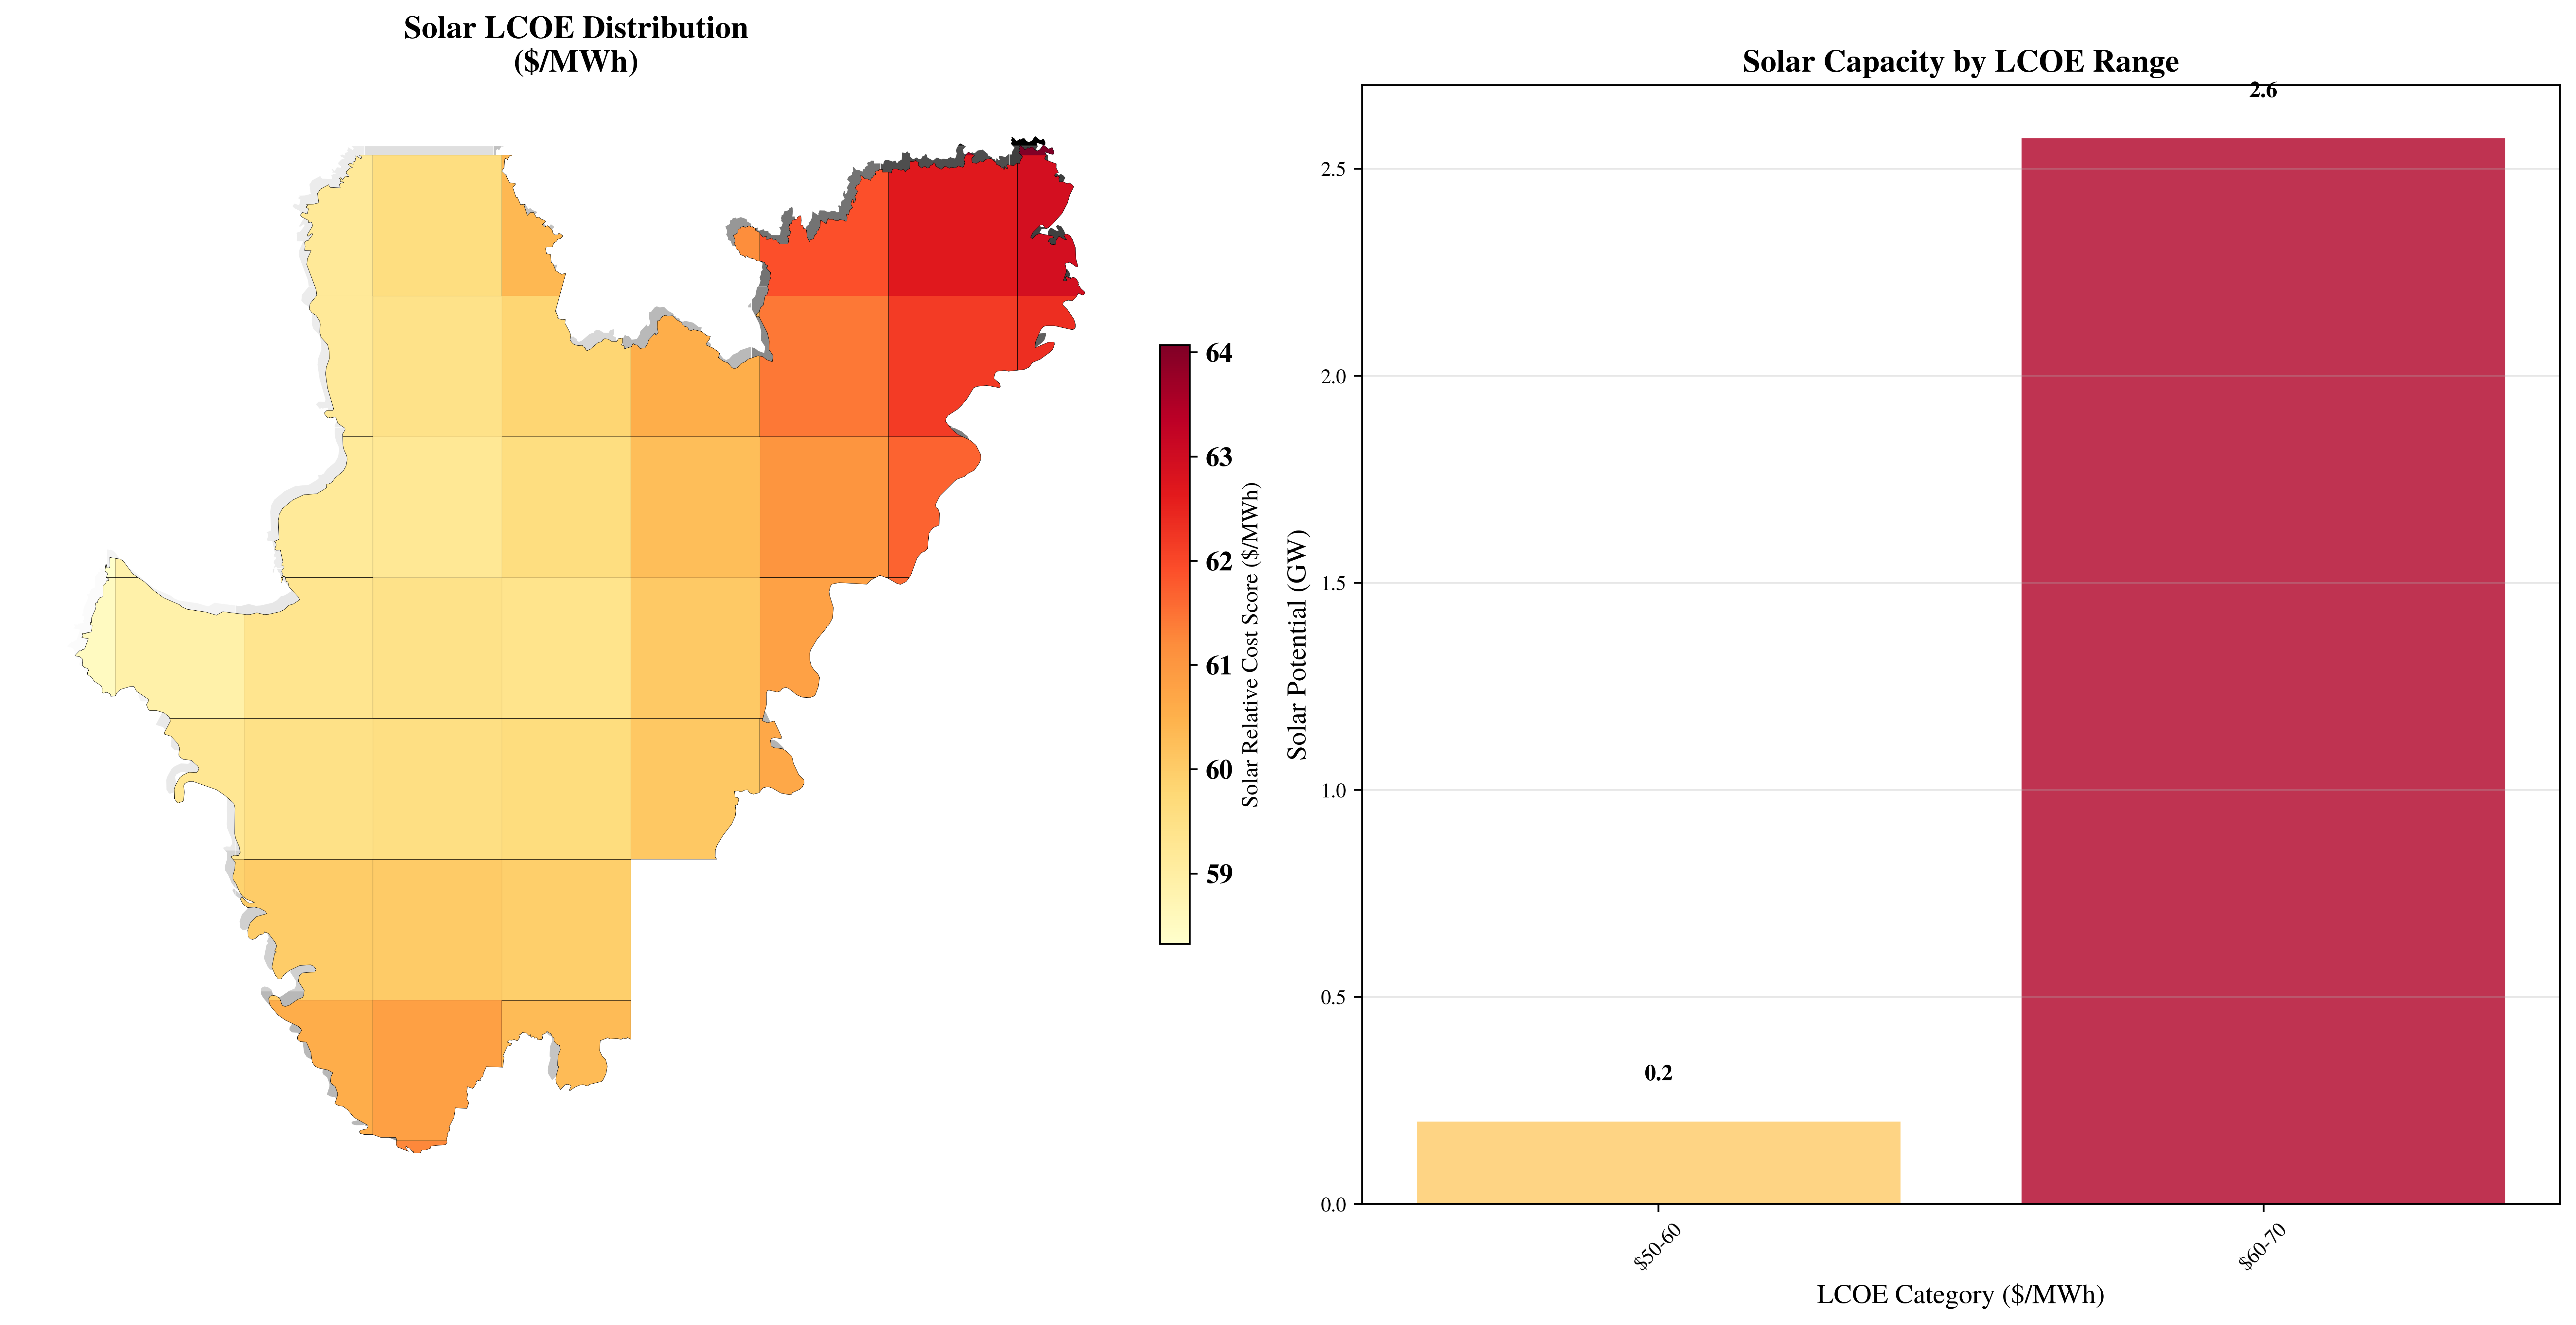

✓ LCOE analysis saved to: ../vis/Bangladesh/Bangladesh_Solar_LCOE_Analysis.png

💰 Solar LCOE Summary:
  Average LCOE: $60.4/MWh
  Minimum LCOE: $58.3/MWh
  Maximum LCOE: $64.1/MWh
  Most economic range: $50-60 with 0.2 GW potential


In [32]:
# LCOE (Levelized Cost of Energy) Analysis for Solar
if BGD_store and 'lcoe_solar' in BGD_cells.columns:
    
    # Define LCOE bins for categorization
    solar_bins = [0, 50, 60, 70, 80, 100, float('inf')]
    solar_labels = ['<$50', '$50-60', '$60-70', '$70-80', '$80-100', '>$100']
    
    # Categorize LCOE into bins
    BGD_cells['solar_lcoe_category'] = pd.cut(
        BGD_cells['lcoe_solar'], 
        bins=solar_bins, 
        labels=solar_labels, 
        include_lowest=True
    )
    
    # Create LCOE visualization
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
    
    # Map plot
    vis.get_data_in_map_plot(
        BGD_cells, 
        resource_type='solar',
        datafield='score',  # This typically corresponds to LCOE
        ax=ax1, 
        show=False
    )
    
    # Add existing VREs if available
    if existing_VREs_gdf is not None:
        solar_projects = existing_VREs_gdf[
            existing_VREs_gdf['Technology'].str.lower().str.contains('solar', na=False)
        ]
        if len(solar_projects) > 0:
            solar_projects.plot(
                ax=ax1, color='None', edgecolor='orangered', 
                markersize=80, linewidth=2, marker='s', 
                alpha=1, zorder=5, label='Existing Solar'
            )
            ax1.legend(loc='upper right', fontsize=10, frameon=True)
    
    ax1.set_title("Solar LCOE Distribution\n($/MWh)", fontsize=14, fontweight='bold')
    
    # Bar chart of capacity by LCOE category
    lcoe_capacity = (
        BGD_cells.groupby('solar_lcoe_category')['potential_capacity_solar']
        .sum().div(1e3)  # Convert to GW
        .reindex(solar_labels, fill_value=0)
    )
    
    # Remove empty categories
    lcoe_capacity = lcoe_capacity[lcoe_capacity > 0]
    
    # Color mapping for consistency
    colors = plt.cm.YlOrRd(np.linspace(0.3, 0.9, len(lcoe_capacity)))
    
    ax2.bar(range(len(lcoe_capacity)), lcoe_capacity.values, color=colors, alpha=0.8)
    ax2.set_xticks(range(len(lcoe_capacity)))
    ax2.set_xticklabels(lcoe_capacity.index, rotation=45)
    ax2.set_ylabel('Solar Potential (GW)', fontsize=12)
    ax2.set_xlabel('LCOE Category ($/MWh)', fontsize=12)
    ax2.set_title('Solar Capacity by LCOE Range', fontsize=14, fontweight='bold')
    ax2.grid(axis='y', alpha=0.3)
    
    # Add value labels on bars
    for i, v in enumerate(lcoe_capacity.values):
        ax2.text(i, v + 0.1, f'{v:.1f}', ha='center', fontweight='bold')
    
    plt.tight_layout()
    
    # Save the plot
    save_path = Path(f'../vis/{country_kwd}/Bangladesh_Solar_LCOE_Analysis.png')
    save_path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    plt.show()
    
    # Calculate LCOE statistics
    mean_lcoe = BGD_cells['lcoe_solar'].mean()
    min_lcoe = BGD_cells['lcoe_solar'].min()
    max_lcoe = BGD_cells['lcoe_solar'].max()
    
    print(f"✓ LCOE analysis saved to: {save_path}")
    print(f"\n💰 Solar LCOE Summary:")
    print(f"  Average LCOE: ${mean_lcoe:.1f}/MWh")
    print(f"  Minimum LCOE: ${min_lcoe:.1f}/MWh")
    print(f"  Maximum LCOE: ${max_lcoe:.1f}/MWh")
    print(f"  Most economic range: {lcoe_capacity.index[0]} with {lcoe_capacity.iloc[0]:.1f} GW potential")
    
else:
    print("⚠️  No LCOE data available for analysis")

## Section 8: Show Transmission Infrastructure

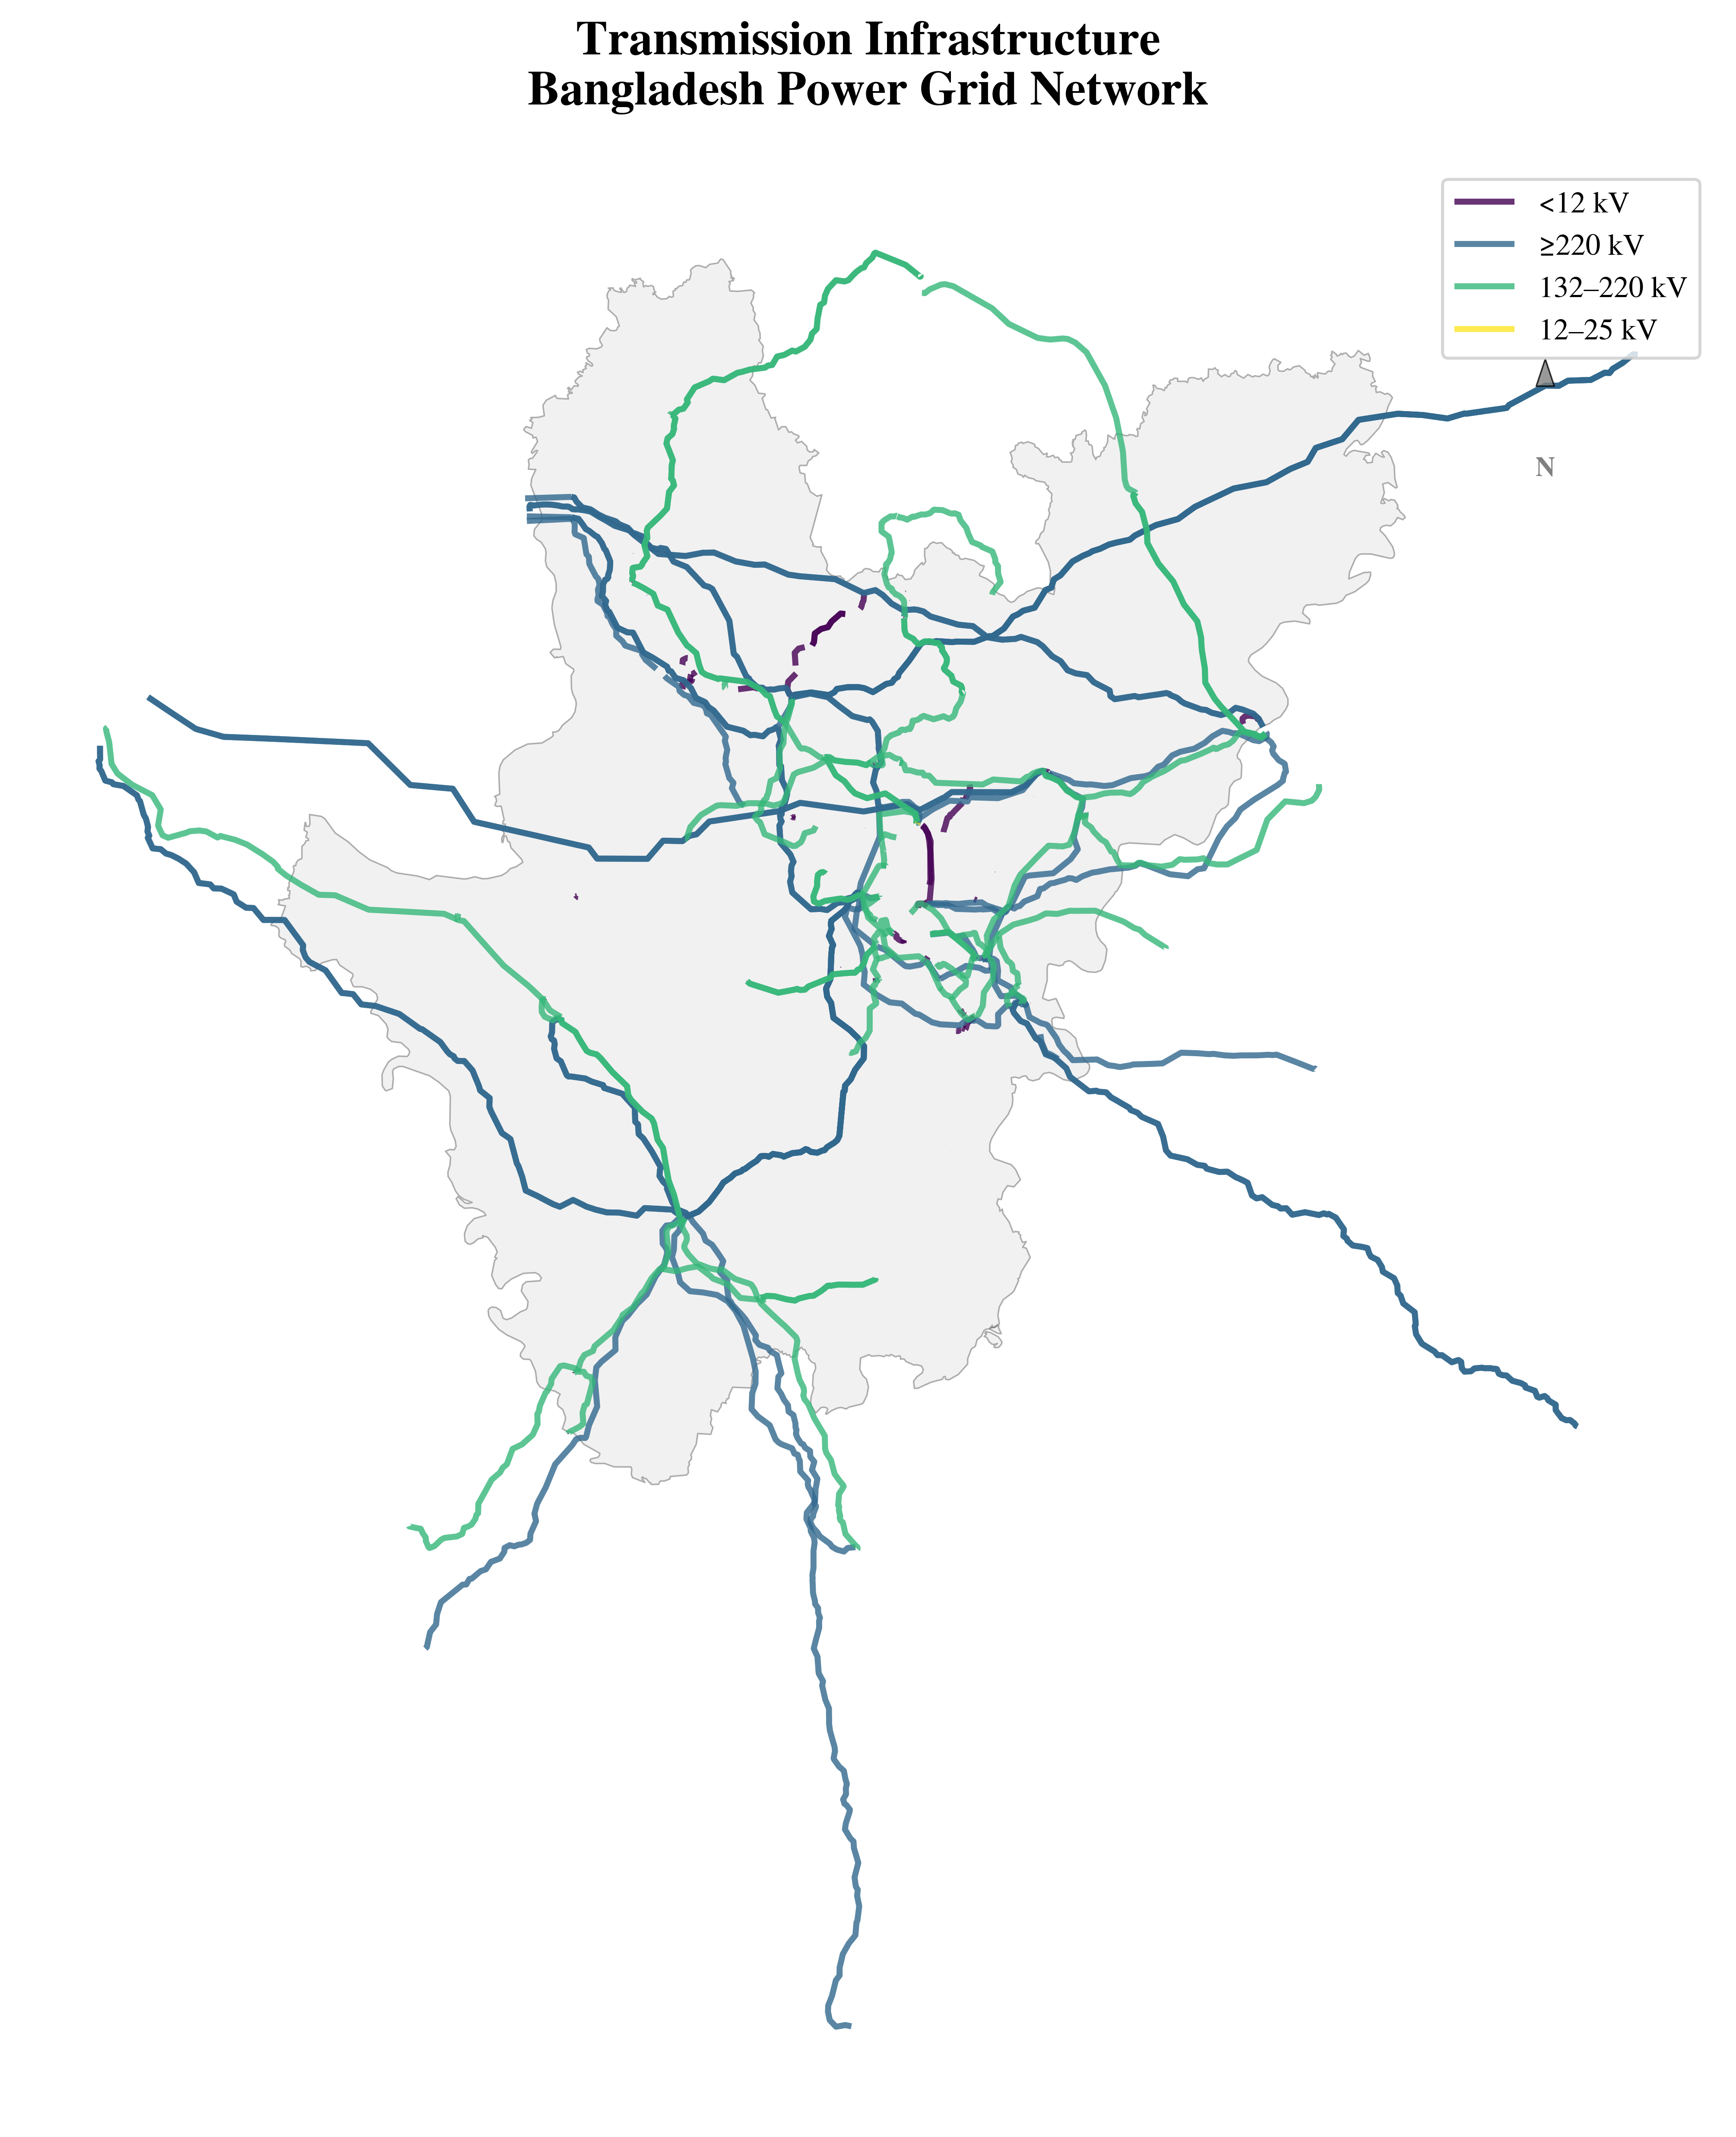

✓ Transmission grid map saved to: ../vis/Bangladesh/Bangladesh_Transmission_Grid.png
  Total transmission lines: 518
  Voltage classes found: ['<12 kV', '≥220 kV', '132–220 kV', '12–25 kV']


In [33]:
# Visualize transmission infrastructure from OpenStreetMap data
if BGD_store:
    # Combine all transmission line data
    all_lines = []
    for region in BGD_store:
        if BGD_store[region]['lines'] is not None:
            all_lines.append(BGD_store[region]['lines'])
    
    if all_lines:
        BGD_lines = gpd.GeoDataFrame(pd.concat(all_lines, ignore_index=True), crs=all_lines[0].crs)
        
        # Process voltage data if available
        if 'voltage' in BGD_lines.columns:
            # Convert to numeric and create voltage classes
            BGD_lines['voltage_kv'] = pd.to_numeric(BGD_lines['voltage'], errors='coerce') / 1000
            
            # Define voltage bins
            bins = [0, 12, 25, 132, 220, float("inf")]
            labels = ["<12 kV", "12–25 kV", "25–132 kV", "132–220 kV", "≥220 kV"]
            BGD_lines['voltage_class'] = pd.cut(BGD_lines['voltage_kv'], bins=bins, labels=labels, right=False)
            
            # Create transmission infrastructure map
            fig, ax = plt.subplots(figsize=(12, 10))
            
            # Plot boundaries first
            if BGD_boundary_dissolved is not None:
                BGD_boundary_dissolved.plot(
                    ax=ax, edgecolor='black', facecolor='lightgray', 
                    linewidth=0.5, alpha=0.3
                )
            
            # Plot transmission lines by voltage class
            unique_classes = BGD_lines['voltage_class'].dropna().unique()
            colors = plt.cm.viridis(np.linspace(0, 1, len(unique_classes)))
            
            for i, voltage_class in enumerate(unique_classes):
                lines_subset = BGD_lines[BGD_lines['voltage_class'] == voltage_class]
                lines_subset.plot(
                    ax=ax, color=colors[i], linewidth=2, 
                    alpha=0.8, label=str(voltage_class)
                )
            
            # Add existing VREs if available
            if existing_VREs_gdf is not None:
                existing_VREs_gdf.plot(
                    ax=ax, color='red', markersize=100, alpha=0.8, 
                    marker='*', label='Existing RE Projects', zorder=5
                )
            
            ax.set_title("Transmission Infrastructure\nBangladesh Power Grid Network", 
                        fontsize=16, fontweight='bold', pad=20)
            ax.legend(loc='upper right', fontsize=10, frameon=True)
            ax.set_axis_off()
            
            # Add compass
            vis.add_compass_arrow_custom(ax, text_offset=0.04)
            
            plt.tight_layout()
            
            # Save the plot
            save_path = Path(f'../vis/{country_kwd}/Bangladesh_Transmission_Grid.png')
            save_path.parent.mkdir(parents=True, exist_ok=True)
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            
            plt.show()
            
            print(f"✓ Transmission grid map saved to: {save_path}")
            print(f"  Total transmission lines: {len(BGD_lines)}")
            print(f"  Voltage classes found: {list(unique_classes)}")
            
        else:
            print("⚠️  No voltage information available in transmission line data")
    else:
        print("⚠️  No transmission line data available")
else:
    print("❌ No data available for transmission infrastructure visualization")

## Section 9: Generate Resource Potential Summary by Divisions

In [34]:
# Generate comprehensive summary by administrative divisions
if BGD_store and len(BGD_cells) > 0:
    
    # Create division-level summary
    division_summary = []
    
    for region in BGD_store:
        region_cells = BGD_store[region]['cells']
        
        summary_row = {
            'Division_Code': region,
            'Division_Name': region_names[region],
            'Grid_Cells': len(region_cells),
            'Total_Solar_Capacity_MW': region_cells.get('potential_capacity_solar', pd.Series([0])).sum(),
            'Avg_Solar_CF': region_cells.get('solar_CF_mean', pd.Series([0])).mean(),
            'Min_Solar_LCOE': region_cells.get('lcoe_solar', pd.Series([float('inf')])).min(),
            'Avg_Solar_LCOE': region_cells.get('lcoe_solar', pd.Series([0])).mean(),
            'Land_Area_km2': cfg['region_mapping'][region]['land_area_km2']
        }
        
        # Handle wind data if available
        if 'potential_capacity_wind' in region_cells.columns:
            summary_row['Total_Wind_Capacity_MW'] = region_cells['potential_capacity_wind'].sum()
            if 'wind_CF_mean' in region_cells.columns:
                summary_row['Avg_Wind_CF'] = region_cells['wind_CF_mean'].mean()
            if 'lcoe_wind' in region_cells.columns:
                summary_row['Min_Wind_LCOE'] = region_cells['lcoe_wind'].min()
                summary_row['Avg_Wind_LCOE'] = region_cells['lcoe_wind'].mean()
        
        division_summary.append(summary_row)
    
    # Convert to DataFrame
    summary_df = pd.DataFrame(division_summary)
    
    # Clean up infinite values
    summary_df = summary_df.replace([float('inf'), -float('inf')], np.nan)
    
    # Display summary table
    print("🏛️  BANGLADESH RENEWABLE ENERGY POTENTIAL BY ADMINISTRATIVE DIVISIONS")
    print("=" * 80)
    print(summary_df.to_string(index=False, float_format='%.1f'))
    
    # Create visualization of division-level data
    if len(summary_df) > 1:  # Only create plots if we have multiple divisions
        
        fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))
        
        # Solar capacity by division
        ax1.bar(summary_df['Division_Name'], summary_df['Total_Solar_Capacity_MW']/1000, 
                color='orange', alpha=0.7)
        ax1.set_title('Solar Potential by Division (GW)', fontweight='bold')
        ax1.tick_params(axis='x', rotation=45)
        ax1.set_ylabel('Capacity (GW)')
        
        # Solar capacity factor by division
        ax2.bar(summary_df['Division_Name'], summary_df['Avg_Solar_CF'], 
                color='red', alpha=0.7)
        ax2.set_title('Average Solar Capacity Factor', fontweight='bold')
        ax2.tick_params(axis='x', rotation=45)
        ax2.set_ylabel('Capacity Factor')
        ax2.set_ylim(0, 1)
        
        # Solar LCOE by division
        ax3.bar(summary_df['Division_Name'], summary_df['Avg_Solar_LCOE'], 
                color='gold', alpha=0.7)
        ax3.set_title('Average Solar LCOE ($/MWh)', fontweight='bold')
        ax3.tick_params(axis='x', rotation=45)
        ax3.set_ylabel('LCOE ($/MWh)')
        
        # Land area vs solar potential scatter
        ax4.scatter(summary_df['Land_Area_km2'], summary_df['Total_Solar_Capacity_MW']/1000, 
                   s=100, alpha=0.7, color='green')
        ax4.set_xlabel('Land Area (km²)')
        ax4.set_ylabel('Solar Potential (GW)')
        ax4.set_title('Land Area vs Solar Potential', fontweight='bold')
        
        # Add division labels to scatter plot
        for i, txt in enumerate(summary_df['Division_Name']):
            ax4.annotate(txt, (summary_df['Land_Area_km2'].iloc[i], 
                              summary_df['Total_Solar_Capacity_MW'].iloc[i]/1000),
                        fontsize=8, alpha=0.7)
        
        plt.tight_layout()
        
        # Save the summary plot
        save_path = Path(f'../vis/{country_kwd}/Bangladesh_Division_Summary.png')
        save_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        
        plt.show()
        
        print(f"\\n✓ Division summary plots saved to: {save_path}")
    
    # Save summary table as CSV
    csv_path = Path(f'../results/{country_kwd}/Bangladesh_Division_Summary.csv')
    csv_path.parent.mkdir(parents=True, exist_ok=True)
    summary_df.to_csv(csv_path, index=False)
    print(f"✓ Summary table saved to: {csv_path}")
    
    # Calculate national totals
    total_solar_gw = summary_df['Total_Solar_Capacity_MW'].sum() / 1000
    avg_national_cf = summary_df['Avg_Solar_CF'].mean()
    avg_national_lcoe = summary_df['Avg_Solar_LCOE'].mean()
    
    print(f"\\n🇧🇩 NATIONAL SUMMARY:")
    print(f"  Total Solar Potential: {total_solar_gw:.1f} GW")
    print(f"  National Average CF: {avg_national_cf:.3f}")
    print(f"  National Average LCOE: ${avg_national_lcoe:.1f}/MWh")
    
else:
    print("❌ No data available to generate division summary")

🏛️  BANGLADESH RENEWABLE ENERGY POTENTIAL BY ADMINISTRATIVE DIVISIONS
Division_Code Division_Name  Grid_Cells  Total_Solar_Capacity_MW  Avg_Solar_CF  Min_Solar_LCOE  Avg_Solar_LCOE Land_Area_km2  Total_Wind_Capacity_MW
        BD-03         Dhaka          51                   2778.7           0.2            58.3            60.4        20,594                  4783.5
✓ Summary table saved to: ../results/Bangladesh/Bangladesh_Division_Summary.csv
\n🇧🇩 NATIONAL SUMMARY:
  Total Solar Potential: 2.8 GW
  National Average CF: 0.194
  National Average LCOE: $60.4/MWh


## Section 10: Export Final Visualizations and Create Report

In [35]:
# Create a comprehensive final summary and export high-resolution figures
print("📊 FINAL BANGLADESH RENEWABLE ENERGY RESOURCE ANALYSIS SUMMARY")
print("=" * 70)

# Check what data we have available
if BGD_store:
    available_divisions = list(BGD_store.keys())
    total_divisions = len(regions)
    
    print(f"✅ DATA AVAILABILITY:")
    print(f"   • Processed divisions: {len(available_divisions)}/{total_divisions}")
    print(f"   • Available divisions: {[f'{r} ({region_names[r]})' for r in available_divisions]}")
    
    if len(available_divisions) < total_divisions:
        missing_divisions = [r for r in regions if r not in available_divisions]
        print(f"   • Missing divisions: {[f'{r} ({region_names[r]})' for r in missing_divisions]}")
        print(f"   • Note: Run RESource analysis for missing divisions to get complete coverage")
    
    # Generate final combined visualization
    if len(BGD_cells) > 0:
        
        # Create a comprehensive dashboard
        fig = plt.figure(figsize=(20, 16))
        gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)
        
        # Title
        fig.suptitle('Bangladesh Renewable Energy Resource Analysis Dashboard', 
                    fontsize=24, fontweight='bold', y=0.95)
        
        # Map 1: Administrative boundaries
        ax1 = fig.add_subplot(gs[0, 0])
        if BGD_boundary_dissolved is not None:
            colors = plt.cm.Set3(np.linspace(0, 1, len(BGD_store)))
            for i, (region, data) in enumerate(BGD_store.items()):
                data['boundary'].plot(ax=ax1, color=colors[i], alpha=0.7, edgecolor='black')
                centroid = data['boundary'].geometry.centroid.iloc[0]
                ax1.annotate(region_names[region], (centroid.x, centroid.y), 
                           ha="center", va="center", fontsize=8, fontweight="bold")
        ax1.set_title('Administrative Divisions', fontweight='bold')
        ax1.set_axis_off()
        
        # Map 2: Solar capacity factor
        ax2 = fig.add_subplot(gs[0, 1])
        if 'solar_CF_mean' in BGD_cells.columns or any('CF' in col and 'solar' in col for col in BGD_cells.columns):
            vis.get_data_in_map_plot(BGD_cells, resource_type='solar', datafield='CF', ax=ax2, show=False)
        ax2.set_title('Solar Capacity Factor', fontweight='bold')
        
        # Map 3: Solar capacity potential
        ax3 = fig.add_subplot(gs[0, 2])
        if 'potential_capacity_solar' in BGD_cells.columns:
            vis.get_data_in_map_plot(BGD_cells, resource_type='solar', datafield='capacity', ax=ax3, show=False)
        ax3.set_title('Solar Capacity Potential (MW)', fontweight='bold')
        
        # Chart 1: Division comparison
        ax4 = fig.add_subplot(gs[1, :])
        if len(summary_df) > 0:
            x = np.arange(len(summary_df))
            width = 0.35
            
            ax4_twin = ax4.twinx()
            bars1 = ax4.bar(x - width/2, summary_df['Total_Solar_Capacity_MW']/1000, 
                           width, label='Solar Capacity (GW)', color='orange', alpha=0.7)
            bars2 = ax4_twin.bar(x + width/2, summary_df['Avg_Solar_CF'], 
                                width, label='Avg CF', color='red', alpha=0.7)
            
            ax4.set_xlabel('Administrative Divisions')
            ax4.set_ylabel('Solar Capacity (GW)', color='orange')
            ax4_twin.set_ylabel('Capacity Factor', color='red')
            ax4.set_title('Solar Resource Potential by Division', fontweight='bold')
            ax4.set_xticks(x)
            ax4.set_xticklabels(summary_df['Division_Name'], rotation=45)
            
            # Add legends
            lines1, labels1 = ax4.get_legend_handles_labels()
            lines2, labels2 = ax4_twin.get_legend_handles_labels()
            ax4.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
        
        # Chart 2: LCOE distribution
        ax5 = fig.add_subplot(gs[2, 0])
        if 'lcoe_solar' in BGD_cells.columns:
            BGD_cells['lcoe_solar'].hist(bins=20, ax=ax5, color='gold', alpha=0.7)
            ax5.axvline(BGD_cells['lcoe_solar'].mean(), color='red', linestyle='--', 
                       label=f'Mean: ${BGD_cells["lcoe_solar"].mean():.1f}/MWh')
            ax5.set_xlabel('LCOE ($/MWh)')
            ax5.set_ylabel('Number of Grid Cells')
            ax5.set_title('Solar LCOE Distribution', fontweight='bold')
            ax5.legend()
        
        # Chart 3: Capacity vs Area scatter
        ax6 = fig.add_subplot(gs[2, 1])
        if len(summary_df) > 0:
            scatter = ax6.scatter(summary_df['Land_Area_km2'], 
                                summary_df['Total_Solar_Capacity_MW']/1000,
                                s=summary_df['Avg_Solar_CF']*500, 
                                c=summary_df['Avg_Solar_LCOE'], 
                                cmap='viridis_r', alpha=0.7)
            ax6.set_xlabel('Land Area (km²)')
            ax6.set_ylabel('Solar Potential (GW)')
            ax6.set_title('Area vs Potential\\n(size=CF, color=LCOE)', fontweight='bold')
            plt.colorbar(scatter, ax=ax6, label='LCOE ($/MWh)')
        
        # Statistics summary
        ax7 = fig.add_subplot(gs[2, 2])
        ax7.axis('off')
        
        # Create summary statistics text
        if len(BGD_cells) > 0 and len(summary_df) > 0:
            stats_text = f"""
NATIONAL SUMMARY

📍 Coverage: {len(available_divisions)}/{total_divisions} divisions
🔋 Total Solar Potential: 
   {summary_df['Total_Solar_Capacity_MW'].sum()/1000:.1f} GW
   
⚡ Average Capacity Factor: 
   {summary_df['Avg_Solar_CF'].mean():.3f}
   
💰 Average LCOE: 
   ${summary_df['Avg_Solar_LCOE'].mean():.1f}/MWh
   
🏆 Best Division (LCOE): 
   {summary_df.loc[summary_df['Avg_Solar_LCOE'].idxmin(), 'Division_Name']}
   ${summary_df['Avg_Solar_LCOE'].min():.1f}/MWh
   
📊 Total Grid Cells: {len(BGD_cells)}
🗓️ Analysis Date: {pd.Timestamp.now().strftime('%Y-%m-%d')}
            """
            ax7.text(0.1, 0.9, stats_text, transform=ax7.transAxes, fontsize=11,
                    verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))
        
        # Save the dashboard
        dashboard_path = Path(f'../vis/{country_kwd}/Bangladesh_Complete_Dashboard.png')
        dashboard_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(dashboard_path, dpi=300, bbox_inches='tight')
        plt.show()
        
        print(f"\\n✅ EXPORTS COMPLETED:")
        print(f"   📊 Dashboard: {dashboard_path}")
        
        # List all generated files
        vis_dir = Path(f'../vis/{country_kwd}')
        if vis_dir.exists():
            generated_files = list(vis_dir.glob('*.png'))
            print(f"   📁 All visualizations ({len(generated_files)} files):")
            for file in generated_files:
                print(f"      • {file.name}")
        
        results_dir = Path(f'../results/{country_kwd}')
        if results_dir.exists():
            result_files = list(results_dir.glob('*.csv'))
            print(f"   📈 Data exports ({len(result_files)} files):")
            for file in result_files:
                print(f"      • {file.name}")
        
        print(f"\\n🎯 NEXT STEPS:")
        if len(available_divisions) < total_divisions:
            missing = [f'{r} ({region_names[r]})' for r in regions if r not in available_divisions]
            print(f"   1. Run RESource analysis for missing divisions: {missing}")
            print(f"   2. Debug wind resource processing (Global Wind Atlas issue)")
        print(f"   3. Validate results with actual renewable energy projects in Bangladesh")
        print(f"   4. Consider policy constraints and grid integration requirements")
        
else:
    print("❌ No processed data available. Please run RESource analysis first.")

print("\\n" + "=" * 70)
print("📋 Analysis completed! Check the generated files for detailed results.")

📊 FINAL BANGLADESH RENEWABLE ENERGY RESOURCE ANALYSIS SUMMARY
✅ DATA AVAILABILITY:
   • Processed divisions: 1/8
   • Available divisions: ['BD-03 (Dhaka)']
   • Missing divisions: ['BD-01 (Barisal)', 'BD-02 (Chittagong)', 'BD-04 (Khulna)', 'BD-05 (Mymensingh)', 'BD-06 (Rajshahi)', 'BD-07 (Rangpur)', 'BD-08 (Sylhet)']
   • Note: Run RESource analysis for missing divisions to get complete coverage
 └> Please cross check with Solar CF map with GLobal Solar Atlas Data from : https://globalsolaratlas.info/download/country_name
 └> Please cross check with Solar CF map with GLobal Solar Atlas Data from : https://globalsolaratlas.info/download/country_name
 └> Please cross check with Solar CF map with GLobal Solar Atlas Data from : https://globalsolaratlas.info/download/country_name
 └> Please cross check with Solar CF map with GLobal Solar Atlas Data from : https://globalsolaratlas.info/download/country_name


\n✅ EXPORTS COMPLETED:
   📊 Dashboard: ../vis/Bangladesh/Bangladesh_Complete_Dashboard.png
   📁 All visualizations (6 files):
      • Bangladesh_Administrative_Divisions.png
      • Bangladesh_Complete_Dashboard.png
      • Bangladesh_Solar_Capacity.png
      • Bangladesh_Transmission_Grid.png
      • Bangladesh_Solar_LCOE_Analysis.png
      • Bangladesh_Solar_CF.png
   📈 Data exports (1 files):
      • Bangladesh_Division_Summary.csv
\n🎯 NEXT STEPS:
   1. Run RESource analysis for missing divisions: ['BD-01 (Barisal)', 'BD-02 (Chittagong)', 'BD-04 (Khulna)', 'BD-05 (Mymensingh)', 'BD-06 (Rajshahi)', 'BD-07 (Rangpur)', 'BD-08 (Sylhet)']
   2. Debug wind resource processing (Global Wind Atlas issue)
   3. Validate results with actual renewable energy projects in Bangladesh
   4. Consider policy constraints and grid integration requirements
\n======================================================================
📋 Analysis completed! Check the generated files for detailed results.
